# Final Project - Chem 277B
### **Structure-Aware Resistance Prediction in Mycobacterium tuberculosis via MIC Regression**

### Contributors:
Cris Zong, Ethan Chan, Isabella Beatrice Bonomi, Robert Craig Wallace, Sidney Alexa Brooks

### 1) Objective and Goal of the Project

Objective: To develop a machine learning model that predicts M. tuberculosis drug resistance by jointly encoding mutation profiles and drug molecular structure, rather than treating each drug as an independent categorical label.

Goal: To accurately predict resistance confidence levels from mutation loci and Morgan fingerprints, and ultimately generalize to novel anti-TB compounds not present in existing catalogues.

**Note:** prior to going through this walkthrough, instructions for downloading data will be included in the README markdown file.

In [42]:
# Load training data
WHO_data = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

# Let's take a look at the data
print("Shape of the master file:", WHO_data.shape)
print(WHO_data.columns)

Shape of the master file: (48152, 114)
Index(['drug', 'gene', 'mutation', 'variant', 'tier', 'effect',
       'genomic position', 'algorithm_pass_DATASET ALL',
       'Present_SOLO_SR_DATASET ALL', 'Present_SOLO_R_DATASET ALL',
       ...
       'Additional grading criteria applied', 'FINAL CONFIDENCE GRADING',
       'Comment', 'CHANGES vs ver1',
       'Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)',
       'Silent mutation', 'Listed in abridged tables', 'Additional grading',
       'Footnote', 'CHANGES vs ver1.1'],
      dtype='object', length=114)


/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_99701/2059228061.py:2: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  WHO_data = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


In [27]:
# check distribution of WHO grades
print(WHO_data["gene"].value_counts().sort_index())
print(len(WHO_data["gene"].unique()))
print(WHO_data["gene"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

gene
PPE35       674
Rv0010c     511
Rv0565c     393
Rv0678      453
Rv1129c    1806
           ... 
tlyA        214
tsnR        129
ubiA        315
whiB6      1259
whiB7       506
Name: count, Length: 65, dtype: int64
65
gene
PPE35      0.013997
Rv0010c    0.010612
Rv0565c    0.008162
Rv0678     0.009408
Rv1129c    0.037506
             ...   
tlyA       0.004444
tsnR       0.002679
ubiA       0.006542
whiB6      0.026146
whiB7      0.010508
Name: proportion, Length: 65, dtype: float64


In [28]:
# Drop some initial columns that we won't be using, many which are text results and would be difficult to use for models
keep_columns = ['mutation', 'drug','gene','FINAL CONFIDENCE GRADING']
master_file_clean = WHO_data.copy()
master_file_clean = master_file_clean[keep_columns]

In [29]:
# check distribution of WHO grades
print(WHO_data["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(WHO_data["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                    253
2) Assoc w R - Interim         1130
3) Uncertain significance     33906
4) Not assoc w R - Interim    12379
5) Not assoc w R                484
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.005254
2) Assoc w R - Interim        0.023467
3) Uncertain significance     0.704145
4) Not assoc w R - Interim    0.257082
5) Not assoc w R              0.010052
Name: proportion, dtype: float64


In [ ]:


import pandas as pd
master_file_clean = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

master_file_clean["gene"] = master_file_clean["gene"].str.strip()
master_file_clean["mutation"] = master_file_clean["mutation"].str.strip()
master_file_clean["FINAL CONFIDENCE GRADING"] = master_file_clean["FINAL CONFIDENCE GRADING"].str.strip()


# keep only necessary columns
model_df = master_file_clean[[
    "gene",
    "mutation",
    "drug",
    "FINAL CONFIDENCE GRADING",
    "PPV_SOLO_DATASET ALL"
]].copy()

one_hot_df = model_df.copy()

# --- Apply to dataframe ---
features_df = one_hot_df['mutation'].apply(extract_features).apply(pd.Series)
one_hot_df = pd.concat([one_hot_df, features_df], axis=1)

# # --- Check how many fell through to unknown ---
# print(one_hot_df['mut_type'].value_counts())
# unknown_mask = one_hot_df['mut_type'] == 'unknown'
# print(f"\n{unknown_mask.sum()} unparsed mutations:")
# for m in one_hot_df.loc[unknown_mask, 'mutation'].unique()[:200]:
#     print(m)

# --- One-hot encode mut_type, ref, alt ---
one_hot_df = pd.get_dummies(one_hot_df, columns=['gene', 'mut_type', 'ref', 'alt'])


print(f"num features: {len(one_hot_df.columns)}")
for c in one_hot_df.columns:
    print(c)


/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_99701/2610413750.py:180: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file_clean = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


num features: 125
mutation
drug
FINAL CONFIDENCE GRADING
PPV_SOLO_DATASET ALL
position
del_len
ins_len
gene_PPE35
gene_Rv0010c
gene_Rv0565c
gene_Rv0678
gene_Rv1129c
gene_Rv1258c
gene_Rv1979c
gene_Rv2477c
gene_Rv2680
gene_Rv2681
gene_Rv2752c
gene_Rv2983
gene_Rv3083
gene_Rv3236c
gene_aftB
gene_ahpC
gene_atpE
gene_bacA
gene_ccsA
gene_clpC1
gene_ddn
gene_dnaA
gene_eis
gene_embA
gene_embB
gene_embC
gene_embR
gene_ethA
gene_ethR
gene_fbiA
gene_fbiB
gene_fbiC
gene_fgd1
gene_gid
gene_glpK
gene_gyrA
gene_gyrB
gene_hadA
gene_inhA
gene_katG
gene_lpqB
gene_mmpL5
gene_mmpS5
gene_mshA
gene_mtrA
gene_mtrB
gene_ndh
gene_nusG
gene_panD
gene_pepQ
gene_pncA
gene_rplC
gene_rpoA
gene_rpoB
gene_rpoC
gene_rpsA
gene_rpsL
gene_rrl
gene_rrs
gene_sigE
gene_tlyA
gene_tsnR
gene_ubiA
gene_whiB6
gene_whiB7
mut_type_LoF
mut_type_SNV
mut_type_del
mut_type_delins
mut_type_dup
mut_type_extension
mut_type_frameshift
mut_type_ins
mut_type_missense
mut_type_nonsense
mut_type_uncertain
ref_*
ref_A
ref_C
ref_D
ref_E
ref_F
re

In [47]:
# Adding drug embedding columns
embedding_columns_list = [f'drug_embedding_{i}' for i in range(len(drug_embeddings['Amikacin']))]
one_hot_df[embedding_columns_list] = one_hot_df['drug'].map(drug_embeddings).tolist()

# hold out Amikacin and Kanamycin for testing
holdout_drugs = ['Amikacin', 'Kanamycin']
test_df = one_hot_df[one_hot_df['drug'].isin(holdout_drugs)].copy()
train_df = one_hot_df[~one_hot_df['drug'].isin(holdout_drugs)].copy()

one_hot_df = one_hot_df.drop(columns=['drug', 'mutation'])
test_df = test_df.drop(columns=['drug', 'mutation'])
train_df = train_df.drop(columns=['drug', 'mutation'])

print(f"num features: {len(one_hot_df.columns)}")
for c in one_hot_df.columns:
    print(c)
# print(one_hot_df.columns)

/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_99701/1033949817.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  one_hot_df[embedding_columns_list] = one_hot_df['drug'].map(drug_embeddings).tolist()
/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_99701/1033949817.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  one_hot_df[embedding_columns_list] = one_hot_df['drug'].map(drug_embeddings).tolist()
/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_99701/1033949817.py:3: PerformanceWarning: Data

num features: 507
FINAL CONFIDENCE GRADING
PPV_SOLO_DATASET ALL
position
del_len
ins_len
gene_PPE35
gene_Rv0010c
gene_Rv0565c
gene_Rv0678
gene_Rv1129c
gene_Rv1258c
gene_Rv1979c
gene_Rv2477c
gene_Rv2680
gene_Rv2681
gene_Rv2752c
gene_Rv2983
gene_Rv3083
gene_Rv3236c
gene_aftB
gene_ahpC
gene_atpE
gene_bacA
gene_ccsA
gene_clpC1
gene_ddn
gene_dnaA
gene_eis
gene_embA
gene_embB
gene_embC
gene_embR
gene_ethA
gene_ethR
gene_fbiA
gene_fbiB
gene_fbiC
gene_fgd1
gene_gid
gene_glpK
gene_gyrA
gene_gyrB
gene_hadA
gene_inhA
gene_katG
gene_lpqB
gene_mmpL5
gene_mmpS5
gene_mshA
gene_mtrA
gene_mtrB
gene_ndh
gene_nusG
gene_panD
gene_pepQ
gene_pncA
gene_rplC
gene_rpoA
gene_rpoB
gene_rpoC
gene_rpsA
gene_rpsL
gene_rrl
gene_rrs
gene_sigE
gene_tlyA
gene_tsnR
gene_ubiA
gene_whiB6
gene_whiB7
mut_type_LoF
mut_type_SNV
mut_type_del
mut_type_delins
mut_type_dup
mut_type_extension
mut_type_frameshift
mut_type_ins
mut_type_missense
mut_type_nonsense
mut_type_uncertain
ref_*
ref_A
ref_C
ref_D
ref_E
ref_F
ref_G
ref_H
ref_

In [51]:
# ordinally encode resistance grades
grading_scheme = {
    "5) Not assoc w R": 0,
    "4) Not assoc w R - Interim": 1,
    "3) Uncertain significance": 2,
    "2) Assoc w R - Interim": 3,
    "1) Assoc w R": 4
}

train_copy = train_df.copy()
train_copy["grade_ordinal"] = train_copy["FINAL CONFIDENCE GRADING"].map(grading_scheme)
print('original grade ordinal counts:')
print(train_copy['grade_ordinal'].value_counts().sort_index())
train_copy = train_copy.dropna(subset=["grade_ordinal"])
print('dropped na grade ordinal counts:')
print(train_copy['grade_ordinal'].value_counts().sort_index())

original grade ordinal counts:
grade_ordinal
0      400
1    11679
2    30272
3     1126
4      245
Name: count, dtype: int64
dropped na grade ordinal counts:
grade_ordinal
0      400
1    11679
2    30272
3     1126
4      245
Name: count, dtype: int64


In [60]:
test_copy = test_df.copy()
test_copy["grade_ordinal"] = test_copy["FINAL CONFIDENCE GRADING"].map(grading_scheme)
print('original grade ordinal counts:')
print(test_copy['grade_ordinal'].value_counts().sort_index())
test_copy = test_copy.dropna(subset=["grade_ordinal"])
print('dropped na grade ordinal counts:')
print(test_copy['grade_ordinal'].value_counts().sort_index())

original grade ordinal counts:
grade_ordinal
0      84
1     700
2    3634
3       4
4       8
Name: count, dtype: int64
dropped na grade ordinal counts:
grade_ordinal
0      84
1     700
2    3634
3       4
4       8
Name: count, dtype: int64


##### NOW WE CAN START TESTING MODELS #####

In [62]:
# remove rows with NaNs 
train_copy_dropped = train_copy.dropna()
test_copy_dropped = test_copy.dropna()

X_train = train_copy_dropped.drop(columns=['FINAL CONFIDENCE GRADING', 'grade_ordinal'])
y_train = train_copy_dropped['grade_ordinal']
X_test = test_copy_dropped.drop(columns=['FINAL CONFIDENCE GRADING', 'grade_ordinal'])
y_test = test_copy_dropped['grade_ordinal']

In [63]:
# scale the data
scaler = StandardScaler()
XS_train = scaler.fit_transform(X_train)
XS_test = scaler.transform(X_test)

# convert back to dataframe
XS_train = pd.DataFrame(XS_train, columns=X_train.columns)
XS_test = pd.DataFrame(XS_test, columns=X_test.columns)

# Run a logistic regression model as a baseline
baseline_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
baseline_model.fit(XS_train, y_train)
y_pred_baseline = baseline_model.predict(XS_test)
print("Classification Report for Baseline Logistic Regression:")
print(classification_report(y_test, y_pred_baseline))

Classification Report for Baseline Logistic Regression:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.00      0.00      0.00         4
           2       0.98      0.98      0.98      2120
           3       0.00      0.00      0.00         4
           4       0.10      0.12      0.11         8

    accuracy                           0.97      2154
   macro avg       0.22      0.22      0.22      2154
weighted avg       0.97      0.97      0.97      2154



/Users/Bella/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Bella/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Bella/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

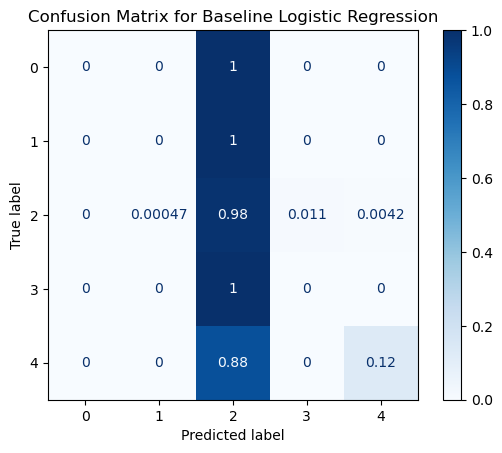

In [64]:
# plot the confusion matrix for the baseline model
cm = confusion_matrix(y_test, y_pred_baseline, labels=baseline_model.classes_, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=baseline_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Baseline Logistic Regression")
plt.show()

In [65]:
# check the balanced accuracy
balanced_accuracy_baseline_random = balanced_accuracy_score(y_test, y_pred_baseline)
print(balanced_accuracy_baseline_random)

0.2218867924528302


### Next we will look at how reducing dimensionality might improve our accuracy scores

In [67]:
# Run PCA only on the fingerprints 

# scale the data
scaler_fp = StandardScaler()

X_PCA_train_scaled = scaler_fp.fit_transform(X_train)
X_PCA_test_scaled = scaler_fp.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)

# run PCA
XS_train_PCA = pca.fit_transform(X_PCA_train_scaled)
XS_test_PCA = pca.transform(X_PCA_test_scaled)

# convert to DF
XS_train_PCA = pd.DataFrame(XS_train_PCA)
XS_test_PCA = pd.DataFrame(XS_test_PCA)
print(XS_train_PCA.head())

          0         1          2         3         4         5         6   \
0  18.255348  3.506470 -19.608093  7.453507  3.908581 -3.276865 -5.741235   
1  18.254290  3.520221 -19.600518  7.464269  3.933833 -3.334085 -5.676055   
2  18.338586  3.597323 -19.561582  7.434554  4.038104 -3.135840 -5.934365   
3  18.317491  3.580557 -19.574559  7.446771  4.016158 -3.212844 -5.834627   
4  18.298134  3.621119 -19.583824  7.535925  3.880014 -3.232045 -6.098220   

         7         8         9   ...        75        76        77         78  \
0 -7.696693  2.613394  5.103144  ...  1.808671 -8.273039 -4.963185  10.884348   
1 -7.734795  2.644062  4.978476  ...  1.917250 -8.704420 -5.555860  10.507103   
2 -7.542202  2.098446  5.976711  ...  1.631192 -8.658256 -5.687447  10.515421   
3 -7.602798  2.248969  5.689507  ...  1.970627 -8.724593 -5.714616  10.594441   
4 -7.381431  2.224329  6.382632  ...  1.750928 -8.937159 -5.967966  10.439380   

         79         80        81        82        

In [70]:
# convert column names to strings
XS_train_PCA.columns = [f"fp_pca_{i}" for i in range(XS_train_PCA.shape[1])]
XS_test_PCA.columns = [f"fp_pca_{i}" for i in range(XS_test_PCA.shape[1])]

# scale the full data again
scaler_full = StandardScaler()
X_trainPCA_final = scaler_full.fit_transform(XS_train_PCA)
X_testPCA_final = scaler_full.transform(XS_test_PCA)

# df
X_trainPCA_final = pd.DataFrame(X_trainPCA_final)
X_testPCA_final = pd.DataFrame(X_testPCA_final)

In [71]:
# Run a logistic regression model with CPA
baseline_model_pca = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
baseline_model_pca.fit(X_trainPCA_final, y_train)
y_pred_pca = baseline_model_pca.predict(X_testPCA_final)
print("Classification Report for Logistic Regression with PCA")
print(classification_report(y_test, y_pred_pca))

Classification Report for Logistic Regression with PCA
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.00      0.00      0.00         4
           2       0.99      0.96      0.97      2120
           3       0.00      0.00      0.00         4
           4       0.27      0.38      0.32         8

    accuracy                           0.94      2154
   macro avg       0.25      0.27      0.26      2154
weighted avg       0.97      0.94      0.96      2154



0.2662264150943396


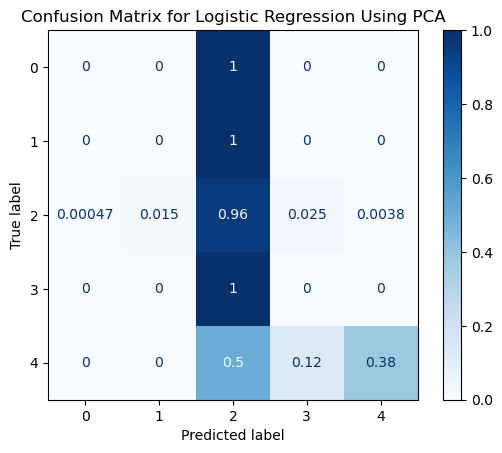

In [72]:
# check the balanced accuracy
balanced_accuracy_pca = balanced_accuracy_score(y_test, y_pred_pca)
print(balanced_accuracy_pca)

# plot the confusion matrix for the baseline model
cm_pca = confusion_matrix(y_test, y_pred_pca, labels=baseline_model_pca.classes_, normalize='true')
disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=baseline_model_pca.classes_)
disp_pca.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Logistic Regression Using PCA")
plt.show()

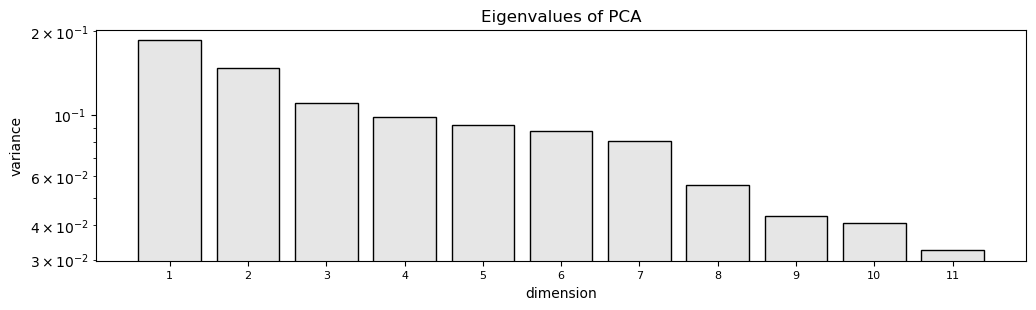

In [56]:
eigenVec = pca.components_
eigenVal = pca.explained_variance_ratio_
xplot = np.arange(1, 12)

fig = plt.figure(figsize=(12, 3))
plt.bar(xplot, eigenVal, color = (0.9, 0.9, 0.9), edgecolor = 'black')
plt.xlabel('dimension')
plt.ylabel('variance')
plt.yscale('log')
plt.xticks(xplot, size=8)
plt.title('Eigenvalues of PCA')
plt.show()

In [25]:
# finally let's just run with elastic net
# Fit a logistic regression model using elastic net, balance the data for each class

# copy the dataset first
X_train_regularization = X_train_holdout2.copy()
y_train_regularization = y_train_holdout2.copy()
X_test_regularization = X_test_holdout2.copy()
y_test_regularization = y_test_holdout2.copy()

# scale
scaler_enet = StandardScaler()

X_train_enet = scaler_enet.fit_transform(X_train_regularization)
X_test_enet = scaler_enet.transform(X_test_regularization)

# train model
enet_model = LogisticRegression(max_iter=1000, solver='saga', l1_ratio=0.1,
                                class_weight='balanced', C=0.1, random_state=42)
enet_model.fit(X_train_enet, y_train_regularization)

#predict 
y_pred_enet = enet_model.predict(X_test_enet)

print("Classification Report for Logistic Regression with Elastic Net")
print(classification_report(y_test_regularization, y_pred_enet))

Classification Report for Logistic Regression with Elastic Net
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        83
         2.0       1.00      0.98      0.99      3585
         3.0       0.00      0.00      0.00         4
         4.0       0.83      0.71      0.77         7

    accuracy                           0.98      3679
   macro avg       0.71      0.67      0.69      3679
weighted avg       1.00      0.98      0.99      3679



/Users/Bella/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


0.674178123132098


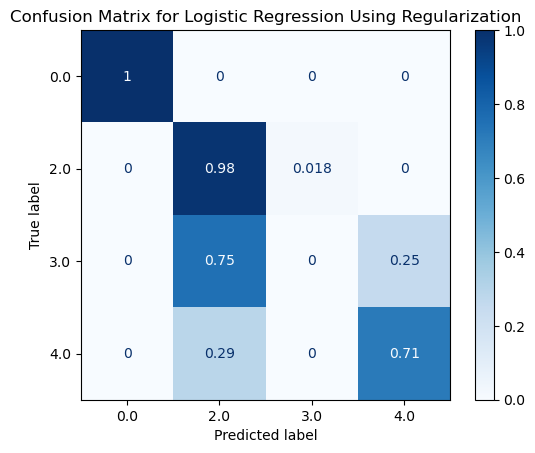

In [27]:
# check the balanced accuracy
balanced_accuracy_regularization = balanced_accuracy_score(y_test_regularization, y_pred_enet)
print(balanced_accuracy_regularization)

# plot the confusion matrix for the baseline model
cm_enet = confusion_matrix(y_test_regularization, y_pred_enet, labels=enet_model.classes_, normalize='true')
disp_enet = ConfusionMatrixDisplay(confusion_matrix=cm_enet, display_labels=enet_model.classes_)
disp_enet.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Logistic Regression Using Regularization")
plt.show()

              precision    recall  f1-score   support

           0       0.12      0.02      0.04        84
           1       0.82      0.99      0.90       700
           2       0.98      0.84      0.90      3634
           3       0.00      0.00      0.00         4
           4       0.02      0.50      0.04         8

    accuracy                           0.84      4430
   macro avg       0.39      0.47      0.37      4430
weighted avg       0.93      0.84      0.88      4430

Balanced Accuracy: 0.47
Epochs run: 18
Best validation score: 0.9659272810427624


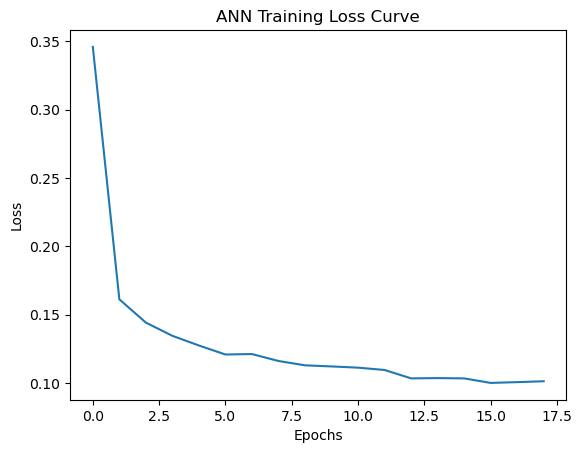

In [57]:
# test using a ANN
# set up ANN
X_train_ANN = X_train_holdout2.copy()
y_train_ANN = y_train_holdout2.copy()
X_test_ANN = X_test_holdout2.copy()
y_test_ANN = y_test_holdout2.copy()

# scale
scaler_ann = StandardScaler()
XS_train_ann = scaler_ann.fit_transform(X_train_ANN)
XS_test_ann = scaler_ann.transform(X_test_ANN)

ann_model = MLPClassifier(hidden_layer_sizes=(64,32),
                                  activation="relu",
                                  alpha=0.001,
                                  max_iter=500,
                                  random_state=42,
                                  early_stopping=True,
                                  validation_fraction=0.1)

ann_model.fit(XS_train_ann, y_train_ANN)
y_pred_ann = ann_model.predict(XS_test_ann)
print(classification_report(y_test_ANN, y_pred_ann))

# Display the accuracy
accuracy_ann = balanced_accuracy_score(y_test_ANN, y_pred_ann)
print(f'Balanced Accuracy: {accuracy_ann:.2f}')

print(f"Epochs run:", ann_model.n_iter_)
print(f"Best validation score: {ann_model.best_validation_score_}")

plt.plot(ann_model.loss_curve_)
plt.title("ANN Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


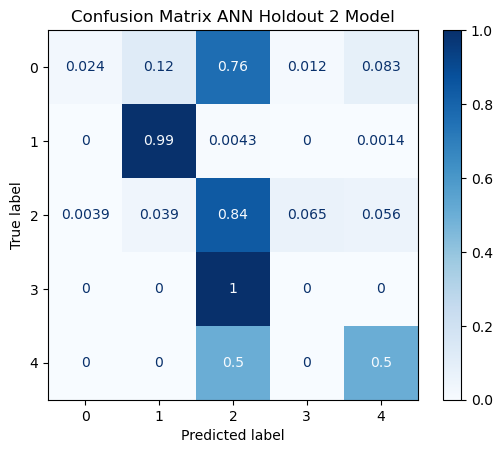

In [60]:
# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm_ann = confusion_matrix(y_test_ANN, y_pred_ann, normalize = 'true', labels=labels)
disp_ANN = ConfusionMatrixDisplay(confusion_matrix = cm_ann)
disp_ANN.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix ANN Holdout 2 Model")
plt.show()

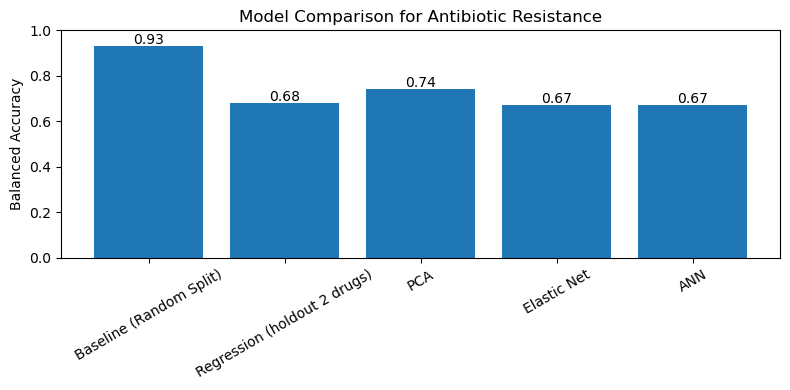

In [36]:
## now let's plot the accuracies for all the models

models = [
    "Baseline (Random Split)",
    "Regression (holdout 2 drugs)",
    "PCA",
    "Elastic Net",
    "ANN"
]

balanced_accuracies = [
    0.93,
    0.68,
    0.74,
    0.67,
    0.67
]

plt.figure(figsize=(8,4))

bars = plt.bar(models, balanced_accuracies)

plt.ylabel("Balanced Accuracy")
plt.title("Model Comparison for Antibiotic Resistance")
plt.ylim(0,1)
plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.2f}", ha="center")
    
plt.tight_layout()
plt.show()